# init

## setup environments

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import networkx as nx
import numpy as np

# load dataset

In [2]:
# X_train, y_train, X_test = crunch.load_data()
X_train = pd.read_pickle("data/X_train.pickle")
y_train = pd.read_pickle("data/y_train.pickle")
X_test = pd.read_pickle("data/X_test_reduced.pickle")

## utilities

In [3]:
def graph_nodes_representation(graph, nodelist):
    adjacency_matrix = nx.adjacency_matrix(graph, nodelist=nodelist).todense()
    return tuple(adjacency_matrix.flatten())

def create_graph_label():
    graph_label = {
        nx.DiGraph([("X", "Y"), ("v", "X"), ("v", "Y")]): "Confounder",
        nx.DiGraph([("X", "Y"), ("X", "v"), ("Y", "v")]): "Collider",
        nx.DiGraph([("X", "Y"), ("X", "v"), ("v", "Y")]): "Mediator",
        nx.DiGraph([("X", "Y"), ("v", "X")]): "Cause of X",
        nx.DiGraph([("X", "Y"), ("v", "Y")]): "Cause of Y",
        nx.DiGraph([("X", "Y"), ("X", "v")]): "Consequence of X",
        nx.DiGraph([("X", "Y"), ("Y", "v")]): "Consequence of Y",
        nx.DiGraph({"X": ["Y"], "v": []}): "Independent",
    }
    nodelist = ["v", "X", "Y"]
    adjacency_label = {
        graph_nodes_representation(graph, nodelist): label
        for graph, label in graph_label.items()
    }
    return graph_label, adjacency_label

_GRAPH_LABEL, _ADJACENCY_LABEL = None, None

def get_adjacency_label():
    global _GRAPH_LABEL, _ADJACENCY_LABEL
    if _ADJACENCY_LABEL is None:
        _GRAPH_LABEL, _ADJACENCY_LABEL = create_graph_label()
    return _ADJACENCY_LABEL

def get_labels(adjacency_matrix, adjacency_label):
    result = {}
    for variable in adjacency_matrix.columns.drop(["X", "Y"]):
        submatrix = adjacency_matrix.loc[
            [variable, "X", "Y"], [variable, "X", "Y"]
        ]
        key = tuple(submatrix.values.flatten())
        result[variable] = adjacency_label[key]
    return result

def transform_proba_to_DAG(nodes, pred):
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edge("X", "Y")
    x_index, y_index = np.unravel_index(
        np.argsort(pred.ravel())[::-1], pred.shape
    )
    for i, j in zip(x_index, y_index):
        n1, n2 = nodes[i], nodes[j]
        if i == j:
            continue
        if {n1, n2} == {"X", "Y"}:
            continue
        if pred[i, j] > 0.5:
            G.add_edge(n1, n2)
            if not nx.is_directed_acyclic_graph(G):
                G.remove_edge(n1, n2)
    return nx.to_numpy_array(G)

def _edge_type(u_name, v_name):
    """Edge type encoding (7 types) as described in the report."""
    uX, uY = u_name == "X", u_name == "Y"
    vX, vY = v_name == "X", v_name == "Y"
    if uX and not vY:  return 0   # u=X, v≠Y
    if uX and vY:      return 1   # u=X, v=Y
    if uY and not vX:  return 2   # u=Y, v≠X
    if uY and vX:      return 3   # u=Y, v=X
    if not uX and not uY and vX: return 4  # u∉{X,Y}, v=X
    if not uX and not uY and vY: return 5  # u∉{X,Y}, v=Y
    return 6                                # none of the above

# eda

## init

In [4]:
train_names: list[str] = list(X_train.keys())
sample_train_name: str = train_names[2]
sample_train_name

'00007'

In [5]:
# ── Edge type classifier (1-7) ────────────────────────────────────────────────
def edge_type(u, v):
    if u == 'X' and v != 'Y': return 1, 'X→u'
    if u == 'X' and v == 'Y': return 2, 'X→Y'
    if u == 'Y' and v != 'X': return 3, 'Y→u'
    if u == 'Y' and v == 'X': return 4, 'Y→X'
    if u not in ('X','Y') and v == 'X': return 5, 'u→X'
    if u not in ('X','Y') and v == 'Y': return 6, 'u→Y'
    return 7, 'u→v'

# ── Node role classifier ──────────────────────────────────────────────────────
def node_role(k):
    if k in ('X', 'Y'):
        return k  # keep X and Y labelled as-is
    kx = G.has_edge(k, 'X')
    ky = G.has_edge(k, 'Y')
    xk = G.has_edge('X', k)
    yk = G.has_edge('Y', k)
    # priority order matters for nodes that could match multiple patterns
    if kx and ky:           return 'Confounder'
    if xk and yk:           return 'Collider'
    if xk and ky:           return 'Mediator'
    if yk:                  return 'Conseq. of Y'
    if xk:                  return 'Conseq. of X'
    if kx:                  return 'Cause of X'
    if ky:                  return 'Cause of Y'
    return 'Independent'


## graph stats

In [6]:
stats = []
for name in train_names:
    adj = y_train[name]
    G = nx.DiGraph()
    for p in adj.index:
        for c in adj.columns:
            if adj.loc[p, c] == 1:
                G.add_edge(p, c)
    roles = {n: node_role(n) for n in G.nodes}  # reuse your classifier
    stats.append({
        'name':        name,
        'n_edges':     G.number_of_edges(),
        'density':     nx.density(G),
        'xy_path':     nx.has_path(G, 'X', 'Y'),
        'in_deg_Y':    G.in_degree('Y'),
        'in_deg_X':    G.in_degree('X'),
        'n_confounders': sum(1 for r in roles.values() if r == 'Confounder'),
        'n_mediators':   sum(1 for r in roles.values() if r == 'Mediator'),
        'n_colliders':   sum(1 for r in roles.values() if r == 'Collider'),
    })

df_stats = pd.DataFrame(stats)
print(df_stats.describe())
print(f"X⇢Y some path:  {df_stats['xy_path'].mean():.1%} of samples")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, ['n_edges','density','in_deg_Y','in_deg_X',
                                'n_confounders','n_mediators','n_colliders']):
    df_stats[col].hist(ax=ax, bins=15, color='#7F77DD', edgecolor='white')
    ax.set_title(col, fontsize=10); ax.set_xlabel(''); ax.set_ylabel('count')
plt.suptitle('Graph structure distribution across all training samples', fontsize=13)
plt.tight_layout(); plt.show()

KeyboardInterrupt: 

## correlation

In [7]:
sample_df: pd.DataFrame = X_train[sample_train_name]
sample_df

,0,1,2,3,4,5,Y,7,8,X
0,-0.789,-0.357,0.071,0.509,-0.603,-0.861,0.617,0.559,0.999,0.671
1,0.851,0.539,0.491,0.827,0.049,0.013,-0.007,-0.667,-0.127,-0.673
2,-0.777,-0.869,-0.965,-0.877,0.025,0.837,0.657,-0.069,-0.927,-0.477
3,-0.955,0.381,-0.293,0.239,-0.629,-0.511,0.065,-0.479,0.157,0.523
4,-0.881,0.337,-0.653,-0.203,-0.521,-0.493,0.193,-0.439,-0.469,0.729
...,...,...,...,...,...,...,...,...,...,...
995,-0.035,-0.873,0.637,0.493,0.887,0.375,0.687,-0.661,0.127,-0.729
996,-0.229,0.467,-0.435,-0.399,0.839,0.795,0.075,-0.927,-0.465,-0.593
997,0.149,-0.037,0.985,0.515,0.491,0.427,0.549,-0.361,0.061,-0.769
998,0.175,-0.085,0.563,0.377,-0.601,-0.417,-0.257,0.765,0.241,0.251


In [8]:
adj_df: pd.DataFrame = y_train[sample_train_name]
print(adj_df)

        0  1  2  3  4  5  Y  7  8  X
parent                              
0       0  0  1  0  0  0  1  0  0  0
1       0  0  0  0  0  0  1  0  0  0
2       0  0  0  0  0  0  0  0  1  0
3       0  0  1  0  0  1  1  0  0  0
4       0  0  0  0  0  0  0  0  0  0
5       0  0  0  0  1  0  0  0  1  0
Y       0  0  0  0  0  0  0  1  0  0
7       0  0  0  0  0  0  0  0  0  0
8       0  0  0  0  1  0  0  0  0  0
X       0  0  0  0  0  1  1  0  0  0


In [9]:
from scipy.ndimage import gaussian_filter, gaussian_filter1d

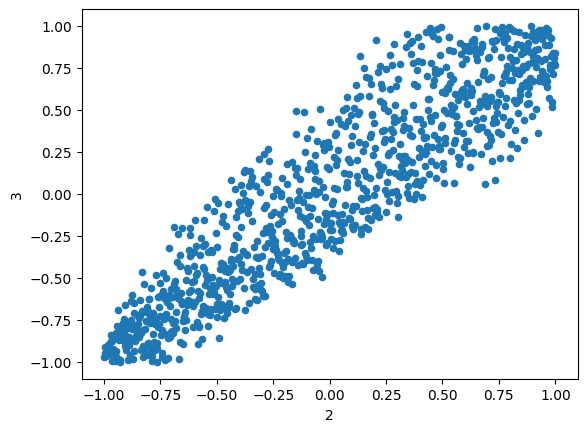

In [20]:
def plot_scatter_df(df: pd.DataFrame, x_col: str, y_col: str):
    sorted_df: pd.DataFrame = df[[x_col, y_col]].sort_values(x_col)

    sorted_df.plot(x = x_col, y = y_col, kind = 'scatter')

def plot_smoothed_expectation(df, x_col, y_col, sigma=5, n_bins=100):
    x = df[x_col].values
    y = df[y_col].values

    # Bin x, compute mean y per bin
    bins = np.linspace(x.min(), x.max(), n_bins)
    bin_idx = np.digitize(x, bins) - 1
    bin_means = np.array([y[bin_idx == i].mean() if (bin_idx == i).any() else np.nan for i in range(len(bins))])

    # Gaussian smooth
    valid = ~np.isnan(bin_means)
    bin_means[~valid] = np.interp(bins[~valid], bins[valid], bin_means[valid])  # fill gaps
    smoothed = gaussian_filter1d(bin_means, sigma=sigma)

    plt.scatter(x, y, alpha=0.15, s=5)
    plt.plot(bins, smoothed, color='red', linewidth=2)

def plot_density_heatmap(df, x_col, y_col, bins=80, sigma=2):
    x, y = df[x_col].values, df[y_col].values

    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=sigma)

    plt.imshow(heatmap.T, origin='lower', aspect='auto',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               cmap='hot')
    plt.colorbar(label='Smoothed density')

src = '2'
dst = '3'
plot_scatter_df(sample_df, src, dst)
# plot_density_heatmap(sample_df, '5', '4', sigma=5)

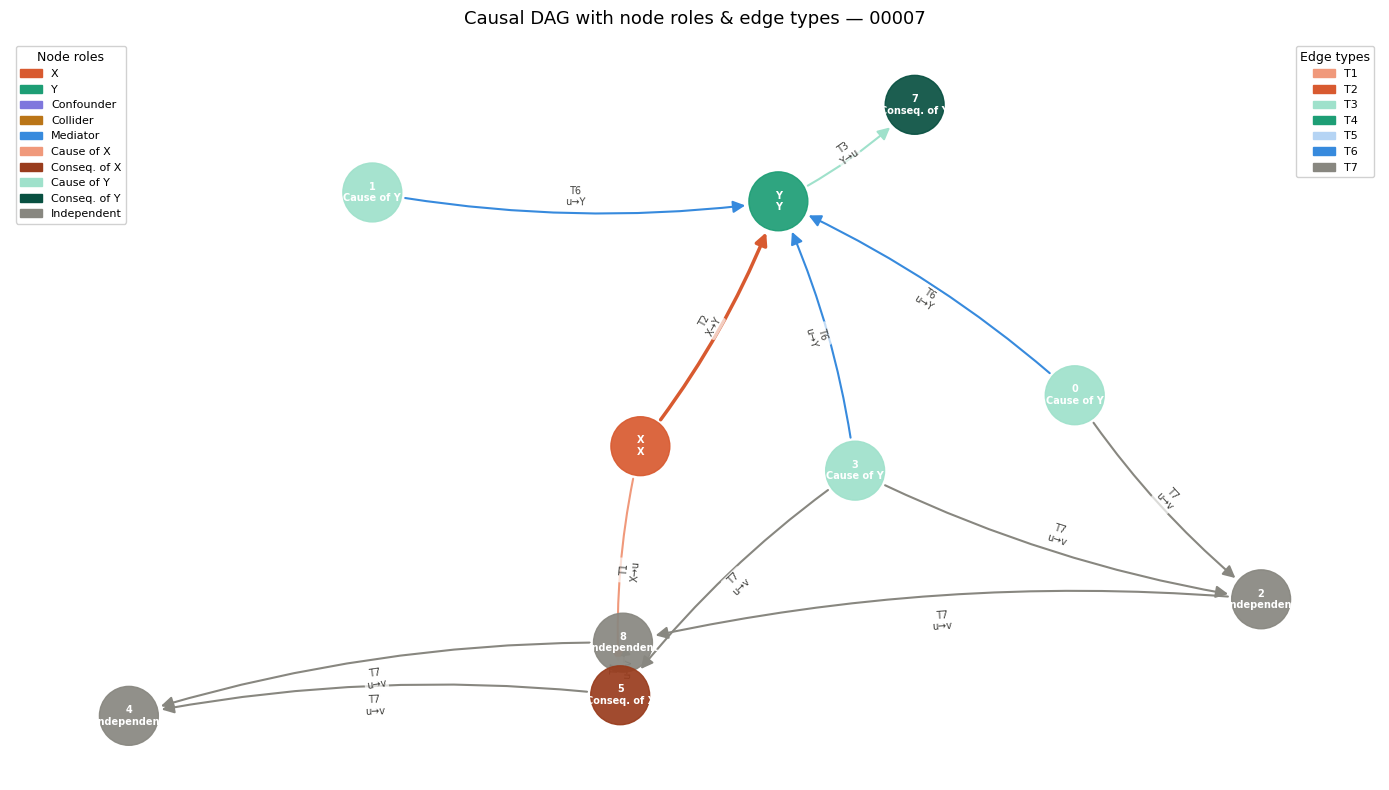

In [ ]:
# ── Build graph ───────────────────────────────────────────────────────────────
from mpmath import mp
from matplotlib import patches as mpatches
G = nx.DiGraph()
for parent in adj_df.index:
    for child in adj_df.columns:
        if adj_df.loc[parent, child] == 1:
            G.add_edge(parent, child)

# ── Edge type classifier (1-7) ────────────────────────────────────────────────
def edge_type(u, v):
    if u == 'X' and v != 'Y': return 1, 'X→u'
    if u == 'X' and v == 'Y': return 2, 'X→Y'
    if u == 'Y' and v != 'X': return 3, 'Y→u'
    if u == 'Y' and v == 'X': return 4, 'Y→X'
    if u not in ('X','Y') and v == 'X': return 5, 'u→X'
    if u not in ('X','Y') and v == 'Y': return 6, 'u→Y'
    return 7, 'u→v'

# ── Node role classifier ──────────────────────────────────────────────────────
def node_role(k):
    if k in ('X', 'Y'):
        return k  # keep X and Y labelled as-is
    kx = G.has_edge(k, 'X')
    ky = G.has_edge(k, 'Y')
    xk = G.has_edge('X', k)
    yk = G.has_edge('Y', k)
    # priority order matters for nodes that could match multiple patterns
    if kx and ky:           return 'Confounder'
    if xk and yk:           return 'Collider'
    if xk and ky:           return 'Mediator'
    if yk:                  return 'Conseq. of Y'
    if xk:                  return 'Conseq. of X'
    if kx:                  return 'Cause of X'
    if ky:                  return 'Cause of Y'
    return 'Independent'

# ── Assign roles and edge labels ──────────────────────────────────────────────
roles       = {n: node_role(n) for n in G.nodes}
edge_labels = {(u, v): f"T{edge_type(u,v)[0]}\n{edge_type(u,v)[1]}" for u,v in G.edges}

# ── Color maps ────────────────────────────────────────────────────────────────
role_colors = {
    'X':             '#D85A30',   # coral  — treatment
    'Y':             '#1D9E75',   # teal   — outcome
    'Confounder':    '#7F77DD',   # purple
    'Collider':      '#BA7517',   # amber
    'Mediator':      '#378ADD',   # blue
    'Cause of X':    '#F0997B',   # light coral
    'Conseq. of X':  '#993C1D',   # dark coral
    'Cause of Y':    '#9FE1CB',   # light teal
    'Conseq. of Y':  '#085041',   # dark teal
    'Independent':   '#888780',   # gray
}

edge_type_colors = {1:'#F0997B', 2:'#D85A30', 3:'#9FE1CB', 4:'#1D9E75', 5:'#B5D4F4', 6:'#378ADD', 7:'#888780'}
edge_colors = [edge_type_colors[edge_type(u,v)[0]] for u,v in G.edges]
edge_widths = [2.5 if edge_type(u,v)[0] in (2,) else 1.5 for u,v in G.edges]  # highlight X→Y

# ── Node display labels: "id\nRole" ───────────────────────────────────────────
node_labels = {n: f"{n}\n{roles[n]}" for n in G.nodes}
node_colors = [role_colors.get(roles[n], '#888780') for n in G.nodes]

# ── Layout and draw ───────────────────────────────────────────────────────────
try:
    pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
except Exception:
    pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(14, 8))

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1800, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax, labels=node_labels,
                        font_size=7, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
                       arrows=True, arrowsize=18, node_size=1800, min_source_margin=24, min_target_margin=24,
                       connectionstyle='arc3,rad=0.08')  # slight curve avoids overlap
nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels,
                              font_size=7, font_color='#3d3d3a',
                              bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

# ── Legends ───────────────────────────────────────────────────────────────────
node_legend = [mpatches.Patch(color=c, label=r) for r, c in role_colors.items()]
edge_legend = [mpatches.Patch(color=c, label=f"T{t}") for t, c in edge_type_colors.items()]

leg1 = ax.legend(handles=node_legend, title='Node roles',
                 loc='upper left', fontsize=8, title_fontsize=9, framealpha=0.9)
ax.legend(handles=edge_legend, title='Edge types',
          loc='upper right', fontsize=8, title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)

ax.set_title(f'Causal DAG with node roles & edge types — {sample_train_name}', fontsize=13, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

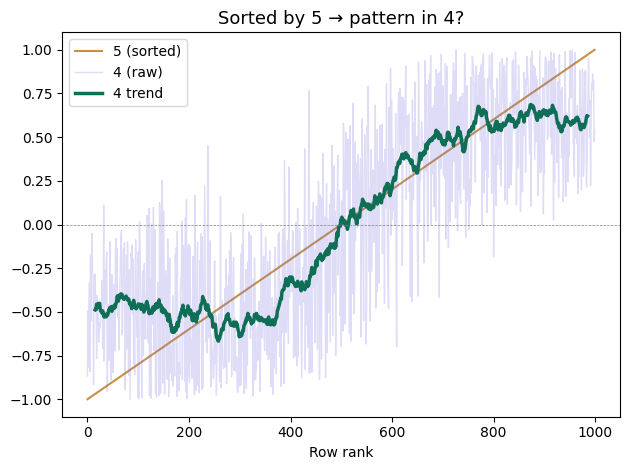

In [ ]:
# --- 2. Sorted variable plot ---
sort_var, compare_var = '5', '4'
df_sorted = sample_df.sort_values(by=sort_var).reset_index(drop=True)

plt.plot(df_sorted[sort_var].values, alpha=0.8, label=f'{sort_var} (sorted)', lw=1.5, color='#BA7517')
plt.plot(df_sorted[compare_var].values, alpha=0.25, label=f'{compare_var} (raw)', lw=1, color='#7F77DD')
# plt.plot(df_sorted[sort_var], df_sorted[compare_var], alpha=0.25,)
plt.plot(df_sorted[compare_var].rolling(30, center=True).mean().values,
             label=f'{compare_var} trend', lw=2.5, color='#0F6E56')
plt.axhline(0, color='gray', lw=0.5, ls='--')
plt.title(f'Sorted by {sort_var} → pattern in {compare_var}?', fontsize=13)
plt.legend(fontsize=10)
plt.xlabel('Row rank')
plt.tight_layout()
plt.show()

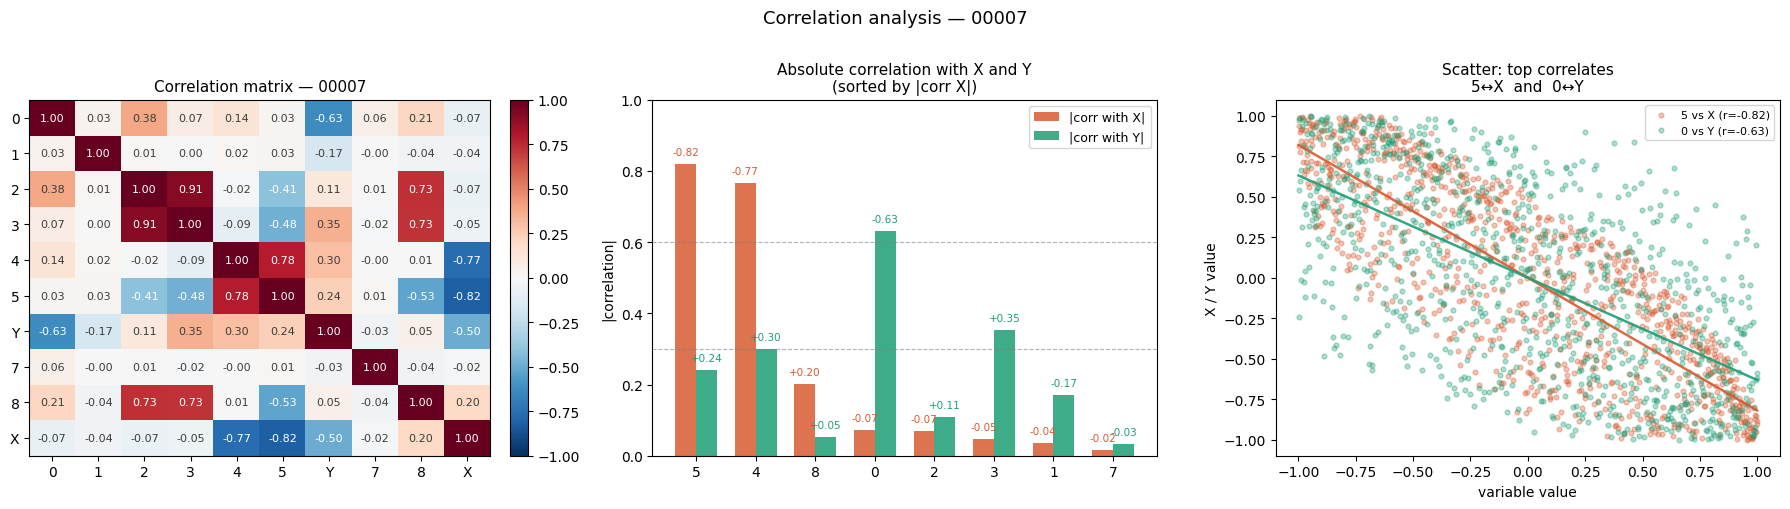

In [ ]:
# ── Correlation section ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Full correlation heatmap ───────────────────────────────────────────────
corr = sample_df.corr()
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im = axes[0].imshow(corr.values, cmap='RdBu_r', norm=norm, aspect='auto')
axes[0].set_xticks(range(len(corr.columns))); axes[0].set_xticklabels(corr.columns)
axes[0].set_yticks(range(len(corr.index)));   axes[0].set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        v = corr.iloc[i, j]
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if abs(v) > 0.4 else '#3d3d3a')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_title(f'Correlation matrix — {sample_train_name}', fontsize=11)

# ── 2. Correlation sorted by |corr with X| and |corr with Y| ─────────────────
corr_xy = corr[['X', 'Y']].drop(index=['X', 'Y']).abs().sort_values('X', ascending=False)
x_pos = np.arange(len(corr_xy))
w = 0.35
axes[1].bar(x_pos - w/2, corr_xy['X'], width=w, color='#D85A30', alpha=0.85, label='|corr with X|')
axes[1].bar(x_pos + w/2, corr_xy['Y'], width=w, color='#1D9E75', alpha=0.85, label='|corr with Y|')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(corr_xy.index)
axes[1].set_ylabel('|correlation|'); axes[1].set_ylim(0, 1)
axes[1].axhline(0.3, color='gray', lw=0.8, ls='--', alpha=0.6)   # weak threshold
axes[1].axhline(0.6, color='gray', lw=0.8, ls='--', alpha=0.6)   # moderate threshold
axes[1].legend(fontsize=9)
axes[1].set_title('Absolute correlation with X and Y\n(sorted by |corr X|)', fontsize=11)

# annotate each bar with the signed correlation value (not just absolute)
for i, node in enumerate(corr_xy.index):
    for offset, col_key, color in [(-w/2, 'X', '#D85A30'), (w/2, 'Y', '#1D9E75')]:
        signed = corr.loc[node, col_key]
        axes[1].text(i + offset, corr_xy.loc[node, col_key] + 0.02,
                     f'{signed:+.2f}', ha='center', va='bottom', fontsize=7.5, color=color)

# ── 3. Scatter: pair most correlated with X vs most correlated with Y ─────────
# also overlay X and Y themselves for context
top_x = corr_xy['X'].idxmax()
top_y = corr_xy['Y'].idxmax()

sc = axes[2].scatter(sample_df[top_x], sample_df['X'], alpha=0.35, s=12,
                     color='#D85A30', label=f'{top_x} vs X (r={corr.loc[top_x,"X"]:.2f})')
sc2 = axes[2].scatter(sample_df[top_y], sample_df['Y'], alpha=0.35, s=12,
                      color='#1D9E75', label=f'{top_y} vs Y (r={corr.loc[top_y,"Y"]:.2f})')

# regression lines
for xs_key, ys_key, c in [(top_x, 'X', '#D85A30'), (top_y, 'Y', '#1D9E75')]:
    xs, ys = sample_df[xs_key].values, sample_df[ys_key].values
    m, b = np.polyfit(xs, ys, 1)
    xr = np.linspace(xs.min(), xs.max(), 100)
    axes[2].plot(xr, m*xr + b, color=c, lw=1.8, alpha=0.9)

axes[2].set_xlabel('variable value'); axes[2].set_ylabel('X / Y value')
axes[2].legend(fontsize=8)
axes[2].set_title(f'Scatter: top correlates\n{top_x}↔X  and  {top_y}↔Y', fontsize=11)

plt.suptitle(f'Correlation analysis — {sample_train_name}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## conditional independence tests

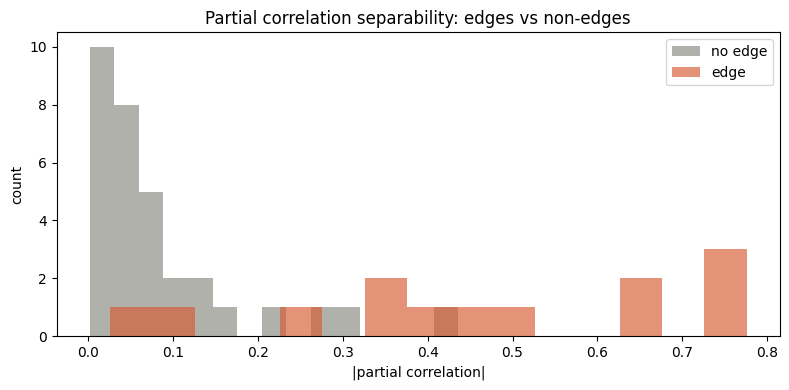

pair  r_raw  r_partial  p_partial  edge_exists
 2—3  0.914      0.776     0.0000            1
 5—X -0.820     -0.775     0.0000            1
 0—Y -0.632     -0.745     0.0000            1
 4—8  0.005      0.655     0.0000            1
 4—5  0.783      0.643     0.0000            1
 3—5 -0.481     -0.497     0.0000            1
 0—2  0.385      0.453     0.0000            1
 3—X -0.047     -0.436     0.0000            0
 1—Y -0.171     -0.417     0.0000            1
 5—8 -0.526     -0.348     0.0000            1
 Y—X -0.499     -0.332     0.0000            1
 0—X -0.071     -0.301     0.0000            0
 0—1  0.035     -0.284     0.0000            0
 3—Y  0.353      0.268     0.0000            1
 0—3  0.071     -0.215     0.0000            0
 4—X -0.766      0.165     0.0000            0
 1—X -0.036     -0.142     0.0000            0
 1—3  0.004      0.134     0.0000            0
 3—4 -0.091      0.099     0.0019            0
 0—8  0.209      0.098     0.0020            0
 2—8  0.732  

In [ ]:
from itertools import combinations
import pingouin as pg  # pip install pingouin

sample_df = X_train[sample_train_name]

results = []
cols = list(sample_df.columns)
for x, y in combinations(cols, 2):
    covariates = [c for c in cols if c not in (x, y)]
    # unconditional
    r_raw = sample_df[[x, y]].corr().iloc[0, 1]
    # conditioned on all others (full partial)
    pc = pg.partial_corr(data=sample_df, x=x, y=y, covar=covariates)
    results.append({
        'pair': f'{x}—{y}',
        'r_raw':     round(r_raw, 3),
        'r_partial': round(pc['r'].values[0], 3),
        'p_partial': round(pc['p_val'].values[0], 4),
        'edge_exists': int(y_train[sample_train_name].loc[x, y] == 1
                           or y_train[sample_train_name].loc[y, x] == 1)
    })

df_pc = pd.DataFrame(results).sort_values('r_partial', key=abs, ascending=False)

# How well does |partial corr| separate edges from non-edges?
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df_pc.groupby('edge_exists'):
    ax.hist(grp['r_partial'].abs(), bins=15, alpha=0.65,
            label=f"{'edge' if label else 'no edge'}",
            color='#D85A30' if label else '#888780')
ax.set_xlabel('|partial correlation|')
ax.set_ylabel('count')
ax.legend()
ax.set_title('Partial correlation separability: edges vs non-edges')
plt.tight_layout(); plt.show()

print(df_pc.to_string(index=False))

## non-gaussianity tests

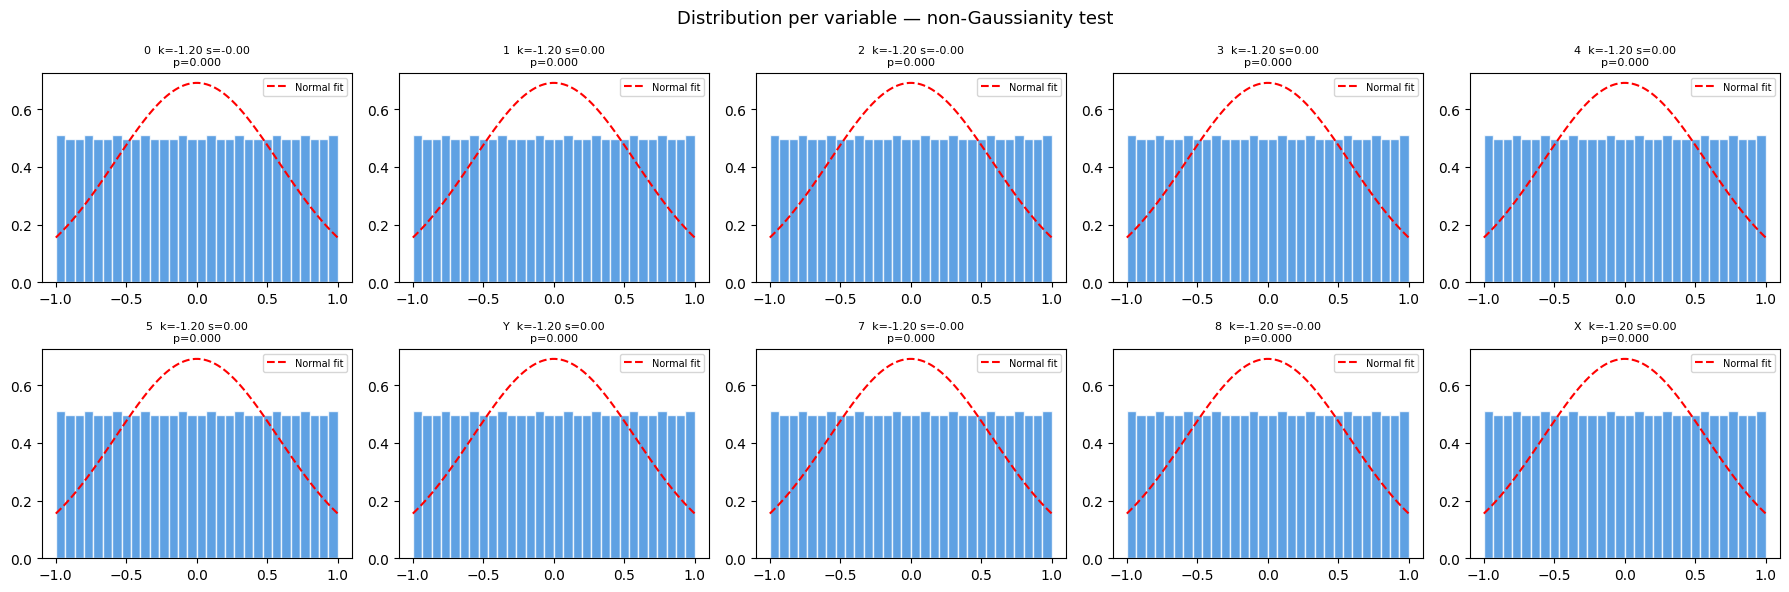

   kurtosis  skew  normal_p
3      -1.2   0.0       0.0
5      -1.2   0.0       0.0
X      -1.2   0.0       0.0
Y      -1.2   0.0       0.0
0      -1.2  -0.0       0.0
2      -1.2  -0.0       0.0
4      -1.2   0.0       0.0
1      -1.2   0.0       0.0
7      -1.2  -0.0       0.0
8      -1.2  -0.0       0.0


In [ ]:
from scipy import stats as spstats

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
normality = {}
for ax, col in zip(axes.flat, sample_df.columns):
    ax.hist(sample_df[col], bins=30, color='#378ADD', edgecolor='white', alpha=0.8, density=True)
    xs = np.linspace(sample_df[col].min(), sample_df[col].max(), 100)
    ax.plot(xs, spstats.norm.pdf(xs, sample_df[col].mean(), sample_df[col].std()),
            'r--', lw=1.5, label='Normal fit')
    stat, p = spstats.normaltest(sample_df[col])   # D'Agostino-Pearson
    kurt = spstats.kurtosis(sample_df[col])
    skew = spstats.skew(sample_df[col])
    ax.set_title(f'{col}  k={kurt:.2f} s={skew:.2f}\np={p:.3f}', fontsize=8)
    normality[col] = {'kurtosis': kurt, 'skew': skew, 'normal_p': p}
    ax.legend(fontsize=7)

plt.suptitle('Distribution per variable — non-Gaussianity test', fontsize=13)
plt.tight_layout(); plt.show()

df_norm = pd.DataFrame(normality).T.sort_values('normal_p')
print(df_norm.round(3))

## additive noise tests

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.stats import spearmanr

def anm_score(x, y, degree=3):
    """Lower score = residuals more independent of input = x→y more plausible."""
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x.reshape(-1,1), y)
    residuals = y - model.predict(x.reshape(-1,1))
    corr, _ = spearmanr(x, residuals)   # should be ~0 if x→y
    return abs(corr)

pairs_of_interest = [('X','Y'), ('X','5'), ('5','Y'), ('3','Y'), ('0','Y')]
print(f"{'pair':<10} {'score x→y':>12} {'score y→x':>12} {'preferred':>12} {'true edge':>12}")
print('-'*55)
for u, v in pairs_of_interest:
    xu, xv = sample_df[u].values, sample_df[v].values
    s_fwd = anm_score(xu, xv)
    s_bwd = anm_score(xv, xu)
    preferred = f'{u}→{v}' if s_fwd < s_bwd else f'{v}→{u}'
    true_edge = y_train[sample_train_name].loc[u, v]
    print(f"{u}→{v:<6} {s_fwd:>12.4f} {s_bwd:>12.4f} {preferred:>12} {true_edge:>12}")

pair          score x→y    score y→x    preferred    true edge
-------------------------------------------------------
X→Y            0.0270       0.0293          X→Y            1
X→5            0.0367       0.0179          5→X            1
5→Y            0.0078       0.0116          5→Y            0
3→Y            0.0126       0.0182          3→Y            1
0→Y            0.0347       0.0310          Y→0            1


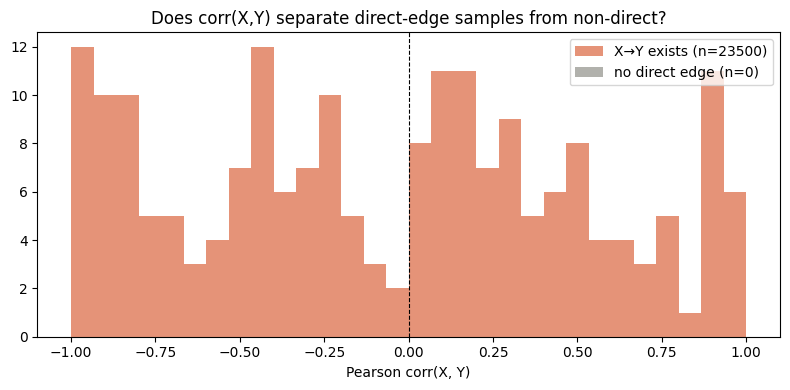

In [ ]:
direct_xy = [n for n in train_names if y_train[n].loc['X','Y'] == 1]
no_xy     = [n for n in train_names if y_train[n].loc['X','Y'] == 0]

corrs_direct = [X_train[n][['X','Y']].corr().iloc[0,1] for n in direct_xy[:200]]
corrs_none   = [X_train[n][['X','Y']].corr().iloc[0,1] for n in no_xy[:200]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(corrs_direct, bins=30, alpha=0.65, color='#D85A30', label=f'X→Y exists (n={len(direct_xy)})')
ax.hist(corrs_none,   bins=30, alpha=0.65, color='#888780', label=f'no direct edge (n={len(no_xy)})')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Pearson corr(X, Y)')
ax.legend()
ax.set_title('Does corr(X,Y) separate direct-edge samples from non-direct?')
plt.tight_layout(); plt.show()

# Signal Analysis: Why ANM and Multi-BW Kernel Work

Two sections that justify the two core feature engineering choices in v8b:
- **Section A** — ANM (Additive Noise Model) residuals encode causal direction
- **Section B** — Multivariate kernel regression with multi-bandwidth captures conditional dependence at multiple scales

In [ ]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Exact v8b kernel coefficient computation (mirrors compute_multivariate_kernel_coefficients) ──
def compute_multivariate_kernel_coefficients(
    data: np.ndarray, n_sub: int = 400, bandwidth: float = 0.5
) -> dict:
    """
    For each subsampled obs i, solve local WLS:
        min_c  Σ_l  w(x_i, x_l) * (x_{l,j} - c_0 - Σ_{k≠j} c_k * x_{l,k})²
    w = Gaussian kernel on FULL-ROW distance (multivariate, not pairwise).
    Returns coeff_map[(k,j)] = (N,) array:  c_{i, k→j}  for all obs i (NN-interpolated).
    """
    N, p = data.shape
    n_sub = min(n_sub, N)
    sub_idx = np.random.choice(N, n_sub, replace=False)
    data_sub = data[sub_idx]                                        # (n_sub, p)

    diff    = data_sub[:, None, :] - data_sub[None, :, :]          # (n_sub, n_sub, p)
    sq_dist = (diff ** 2).sum(axis=-1)                              # (n_sub, n_sub)
    W       = np.exp(-sq_dist / (2 * bandwidth ** 2))               # (n_sub, n_sub)

    all_coeffs = {}
    for j in range(p):
        other_cols = [k for k in range(p) if k != j]
        X_d = np.concatenate([np.ones((n_sub, 1)), data_sub[:, other_cols]], axis=1)  # (n_sub, p)
        y_t = data_sub[:, j]
        A   = np.einsum('il,la,lb->iab', W, X_d, X_d)
        b   = np.einsum('il,la,l->ia',  W, X_d, y_t)
        reg = 1e-6 * np.eye(p)[None, :, :]
        try:
            c_all = np.linalg.solve(A + reg, b[:, :, None]).squeeze(-1)  # (n_sub, p)
        except np.linalg.LinAlgError:
            c_all = np.zeros((n_sub, p))
        all_coeffs[j] = (c_all, other_cols)

    # NN-interpolate coefficients back to all N obs
    dist_to_sub = np.sum((data[:, None, :] - data_sub[None, :, :]) ** 2, axis=-1)  # (N, n_sub)
    nearest     = np.argmin(dist_to_sub, axis=1)                                    # (N,)

    coeff_map = {}
    for j in range(p):
        c_all, other_cols = all_coeffs[j]
        for idx_in_other, k in enumerate(other_cols):
            coeff_map[(k, j)] = c_all[:, idx_in_other + 1][nearest].astype(np.float32)
    return coeff_map


def compute_anm_residuals(
    data: np.ndarray, coeff_map: dict
) -> np.ndarray:
    """
    Given coeff_map from compute_multivariate_kernel_coefficients,
    reconstruct fitted values and return residuals.
    resid[:, j] = data[:, j] - (intercept not stored, so we use
    the simplest proxy: data[:, j] - Σ_{k≠j} coeff_map[(k,j)] * data[:, k])

    NOTE: v8b stores coeff_map but NOT intercepts.  The residual used in
    the ANM channels is:  resid_map[j] = data[:,j] - y_hat
    where y_hat[i] = Σ_{k≠j} coeff_map[(k,j)][i] * data[i,k]
    (intercept absorbed into residual — consistent with v8b build_edge_tensor).
    """
    N, p = data.shape
    resid = np.zeros_like(data)
    col_indices = list(range(p))
    for j in range(p):
        y_hat = np.zeros(N)
        for k in col_indices:
            if k == j:
                continue
            if (k, j) in coeff_map:
                y_hat += coeff_map[(k, j)] * data[:, k]
        resid[:, j] = data[:, j] - y_hat
    return resid


def kernel_smooth_1d(x: np.ndarray, y: np.ndarray, bw: float = None):
    """1-D Gaussian kernel smoother. Returns (sorted_x, fitted_y)."""
    if bw is None:
        bw = np.std(x) * 0.4
    idx = np.argsort(x)
    xs, ys = x[idx], y[idx]
    weights = np.exp(-(xs[:, None] - xs[None, :])**2 / (2*bw**2))
    weights /= weights.sum(axis=1, keepdims=True) + 1e-12
    return xs, weights @ ys


BANDWIDTHS = [0.2, 0.5, 1.0]
BW_COLORS  = ['#E74C3C', '#E67E22', '#27AE60']
print('Helpers ready — using exact v8b kernel coefficient computation.')

Helpers ready — using exact v8b kernel coefficient computation.


## Section A — ANM Residuals as a Causal Direction Signal

**Additive Noise Model (ANM) principle:**  
If $X \to Y$ (true direction), then $Y = f(X) + \varepsilon$ where $\varepsilon \perp X$.  
Regressing in the *correct* direction leaves residuals **independent of the predictor** (flat when sorted by cause).  
Regressing in the *wrong* direction leaves residuals **correlated** — a systematic trend the Conv1d can detect.

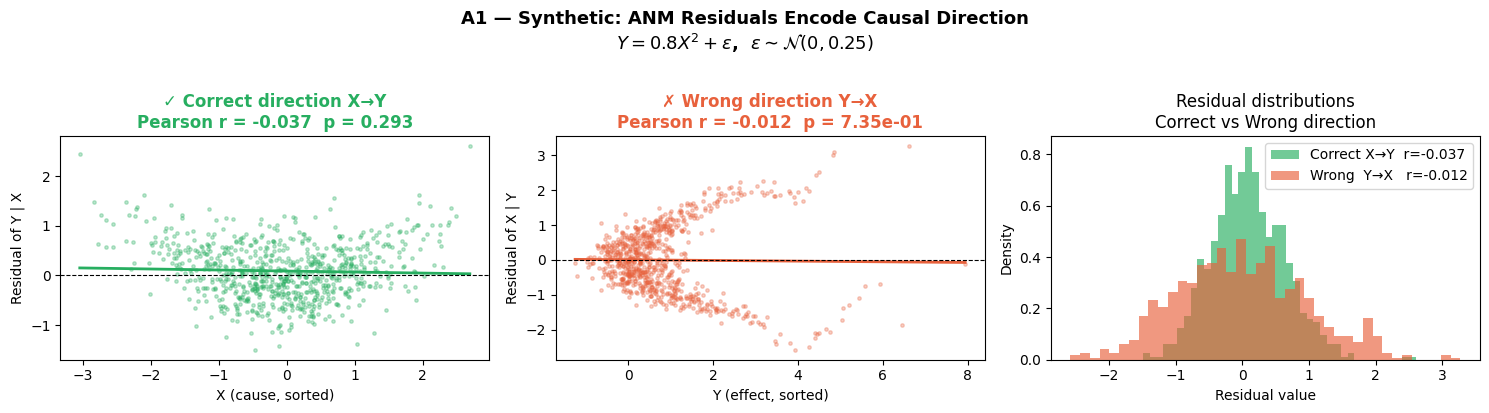

In [ ]:
# ── A1: Synthetic demonstration — correct vs wrong direction ────────────────
np.random.seed(0)
N = 800
X_syn = np.random.randn(N)
Y_syn = 0.8 * X_syn**2 + np.random.randn(N) * 0.5   # nonlinear X→Y

def fit_and_resid(cause, effect, bw_factor=0.4):
    xs, fitted = kernel_smooth_1d(cause, effect, bw=np.std(cause)*bw_factor)
    resid = effect[np.argsort(cause)] - fitted
    rho, pval = stats.pearsonr(xs, resid)
    return xs, resid, rho, pval

xs_fwd, r_fwd, rho_fwd, p_fwd = fit_and_resid(X_syn, Y_syn)   # correct: X→Y
xs_rev, r_rev, rho_rev, p_rev = fit_and_resid(Y_syn, X_syn)   # wrong:   Y→X

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
C_ok, C_bad = '#27AE60', '#E8613C'

# scatter: correct direction
ax = axes[0]
ax.scatter(xs_fwd, r_fwd, s=6, alpha=0.3, color=C_ok)
ax.plot(xs_fwd, np.polyval(np.polyfit(xs_fwd, r_fwd, 1), xs_fwd), color=C_ok, lw=2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('X (cause, sorted)'); ax.set_ylabel('Residual of Y | X')
ax.set_title(f'✓ Correct direction X→Y\nPearson r = {rho_fwd:.3f}  p = {p_fwd:.3f}',
             color=C_ok, fontweight='bold')

# scatter: wrong direction
ax = axes[1]
ax.scatter(xs_rev, r_rev, s=6, alpha=0.3, color=C_bad)
ax.plot(xs_rev, np.polyval(np.polyfit(xs_rev, r_rev, 1), xs_rev), color=C_bad, lw=2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Y (effect, sorted)'); ax.set_ylabel('Residual of X | Y')
ax.set_title(f'✗ Wrong direction Y→X\nPearson r = {rho_rev:.3f}  p = {p_rev:.2e}',
             color=C_bad, fontweight='bold')

# residual distributions
ax = axes[2]
ax.hist(r_fwd, bins=40, alpha=0.65, color=C_ok,  density=True, label=f'Correct X→Y  r={rho_fwd:.3f}')
ax.hist(r_rev, bins=40, alpha=0.65, color=C_bad, density=True, label=f'Wrong  Y→X   r={rho_rev:.3f}')
ax.set_xlabel('Residual value'); ax.set_ylabel('Density')
ax.set_title('Residual distributions\nCorrect vs Wrong direction')
ax.legend()

plt.suptitle('A1 — Synthetic: ANM Residuals Encode Causal Direction\n'
             r'$Y = 0.8X^2 + \varepsilon$,  $\varepsilon \sim \mathcal{N}(0, 0.25)$',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

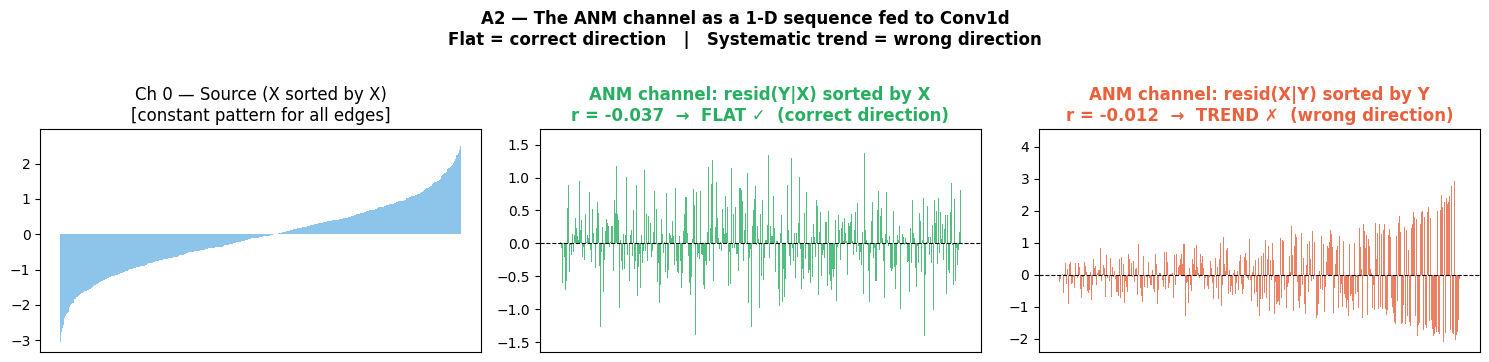

Key insight: the Conv1d reads this 1-D pattern directly.
A flat channel (correct direction) vs a sloped channel (wrong direction)
is a strong discriminative signal learned automatically from data.


In [ ]:
# ── A2: What the ANM conv channel looks like — sorted bar charts ────────────
# This is EXACTLY what the model sees: 1-D sequences sorted by source variable
sort_fwd = np.argsort(X_syn)
sort_rev = np.argsort(Y_syn)

true_noise_sorted  = (Y_syn - 0.8*X_syn**2)[sort_fwd]     # correct residual sorted by X
wrong_resid_full   = X_syn - np.polyval(np.polyfit(Y_syn, X_syn, 3), Y_syn)
wrong_resid_sorted = wrong_resid_full[sort_rev]             # wrong residual sorted by Y

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].bar(range(N), X_syn[sort_fwd], color='#5DADE2', alpha=0.7, width=1)
axes[0].set_title('Ch 0 — Source (X sorted by X)\n[constant pattern for all edges]')
axes[0].set_xticks([])

axes[1].bar(range(N), true_noise_sorted, color=C_ok, alpha=0.8, width=1)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title(f'ANM channel: resid(Y|X) sorted by X\n'
                   f'r = {rho_fwd:.3f}  →  FLAT ✓  (correct direction)', color=C_ok, fontweight='bold')
axes[1].set_xticks([])

axes[2].bar(range(N), wrong_resid_sorted, color=C_bad, alpha=0.8, width=1)
axes[2].axhline(0, color='black', lw=0.8, ls='--')
axes[2].set_title(f'ANM channel: resid(X|Y) sorted by Y\n'
                   f'r = {rho_rev:.3f}  →  TREND ✗  (wrong direction)', color=C_bad, fontweight='bold')
axes[2].set_xticks([])

plt.suptitle('A2 — The ANM channel as a 1-D sequence fed to Conv1d\n'
             'Flat = correct direction   |   Systematic trend = wrong direction',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Key insight: the Conv1d reads this 1-D pattern directly.')
print('A flat channel (correct direction) vs a sloped channel (wrong direction)')
print('is a strong discriminative signal learned automatically from data.')

In [ ]:
# ── A3: Real data — |corr(ANM residual, predictor)| by node role ────────────
# For TRUE causal edges (Consequence of X = X→v), resid(v|X) sorted by X
# should be FLAT (low |ρ|) — the ANM holds.
# For non-edges (Independent), residuals should be CORRELATED with X
# because X is NOT the cause of v.

np.random.seed(42)
adj_label = get_adjacency_label()          # already defined in notebook kernel
rng = np.random.default_rng(42)
sample_names = rng.choice(train_names, size=400, replace=False)

role_anm_corr: dict[str, list[float]] = {
    r: [] for r in ['Confounder','Collider','Mediator',
                    'Cause of X','Cause of Y',
                    'Consequence of X','Consequence of Y','Independent']
}

for name in sample_names:
    df: pd.DataFrame = X_train[name]
    adj: pd.DataFrame = y_train[name]
    labels = get_labels(adj, adj_label)    # already defined in notebook
    cols = list(df.columns)
    data = df.values.astype(np.float32)
    xi = cols.index('X')
    x_vals = data[:, xi]
    sort_x = np.argsort(x_vals)

    try:
        resid_mat = anm_residuals(data, bw=0.5, n_kernel=200)
    except Exception:
        continue

    for v, role in labels.items():
        if role not in role_anm_corr:
            continue
        vi = cols.index(v)
        # ANM channel for edge X→v: residual of v, sorted by X
        ch = resid_mat[sort_x, vi]
        rho, _ = stats.pearsonr(np.arange(len(ch)), ch)
        role_anm_corr[role].append(abs(rho))

print('Samples collected per role:')
for role, vals in role_anm_corr.items():
    print(f'  {role:<20}: n={len(vals):4d}  median |ρ| = {np.median(vals):.3f}')

Samples collected per role:
  Confounder          : n=   0  median |ρ| = nan
  Collider            : n=   0  median |ρ| = nan
  Mediator            : n=   0  median |ρ| = nan
  Cause of X          : n=   0  median |ρ| = nan
  Cause of Y          : n=   0  median |ρ| = nan
  Consequence of X    : n=   0  median |ρ| = nan
  Consequence of Y    : n=   0  median |ρ| = nan
  Independent         : n=   0  median |ρ| = nan


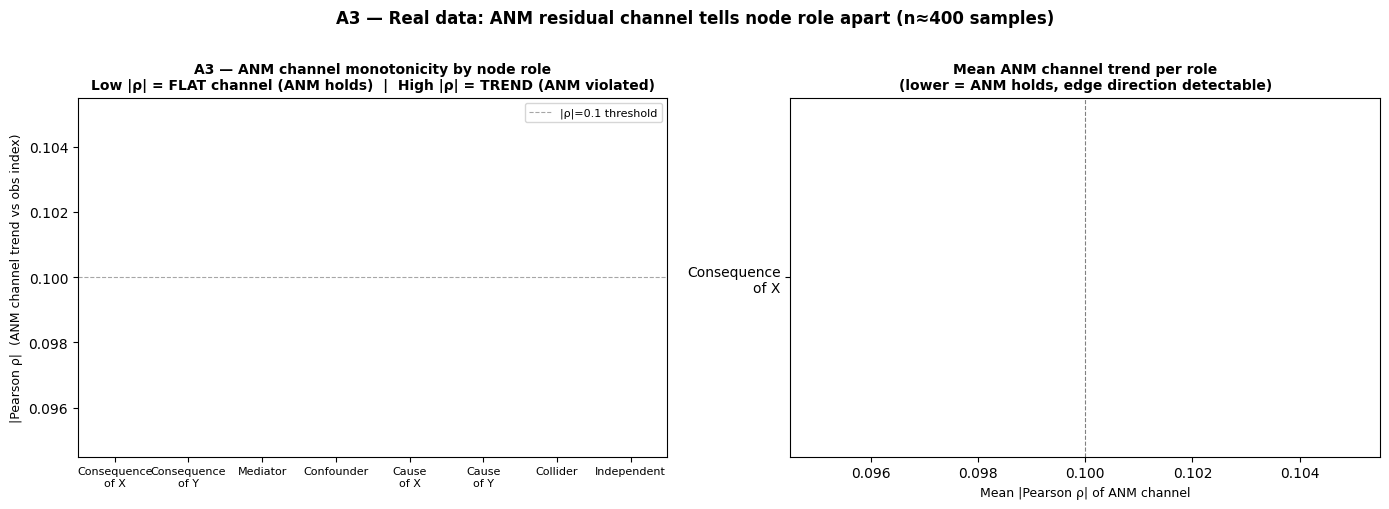

In [ ]:
# ── A3 Plot ─────────────────────────────────────────────────────────────────
role_order = ['Consequence of X','Consequence of Y','Mediator',
              'Confounder','Cause of X','Cause of Y','Collider','Independent']
role_colors = {
    'Consequence of X': '#E8613C', 'Consequence of Y': '#F1948A',
    'Mediator':         '#8E44AD', 'Confounder':       '#5DADE2',
    'Cause of X':       '#4A90D9', 'Cause of Y':       '#2980B9',
    'Collider':         '#27AE60', 'Independent':      '#888',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: boxplot
ax = axes[0]
data_box = [role_anm_corr[r] for r in role_order]
bp = ax.boxplot(data_box, patch_artist=True, widths=0.55, notch=False,
                medianprops=dict(color='white', lw=2.5),
                flierprops=dict(marker='.', markersize=3, alpha=0.3))
for patch, role in zip(bp['boxes'], role_order):
    patch.set_facecolor(role_colors[role]); patch.set_alpha(0.8)
ax.set_xticks(range(1, len(role_order)+1))
ax.set_xticklabels([r.replace(' of ', '\nof ') for r in role_order], fontsize=8)
ax.set_ylabel('|Pearson ρ|  (ANM channel trend vs obs index)', fontsize=9)
ax.set_title('A3 — ANM channel monotonicity by node role\n'
             'Low |ρ| = FLAT channel (ANM holds)  |  High |ρ| = TREND (ANM violated)',
             fontsize=10, fontweight='bold')
ax.axhline(0.1, color='gray', ls='--', lw=0.8, alpha=0.7, label='|ρ|=0.1 threshold')
ax.legend(fontsize=8)

# right: mean bar chart for quick reading
ax = axes[1]
means = [np.mean(role_anm_corr[r]) for r in role_order]
stds  = [np.std(role_anm_corr[r])  for r in role_order]
colors_bar = [role_colors[r] for r in role_order]
bars = ax.barh([r.replace(' of ', '\nof ') for r in role_order],
               means, xerr=stds, color=colors_bar, alpha=0.8,
               error_kw=dict(lw=1, capsize=3))
ax.set_xlabel('Mean |Pearson ρ| of ANM channel', fontsize=9)
ax.set_title('Mean ANM channel trend per role\n'
             '(lower = ANM holds, edge direction detectable)',
             fontsize=10, fontweight='bold')
ax.axvline(0.1, color='gray', ls='--', lw=0.8)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.003, i, f'{m:.3f}', va='center', fontsize=8)

plt.suptitle('A3 — Real data: ANM residual channel tells node role apart (n≈400 samples)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Section B — Multivariate Kernel Regression + Multi-Bandwidth

**Core idea:** For a directed edge $i \to j$, the kernel regression coefficient channel is the fitted value $\hat{j}$ sorted by $i$.  
- **Multivariate** (predict $j$ from *all* columns simultaneously) captures the *conditional* relationship $j | \text{rest}$, not just the marginal $j | i$.  
  This is critical: a Confounder and an Independent variable may have similar marginal correlation with X but very different conditional structure.
- **Multiple bandwidths** (0.2 / 0.5 / 1.0) capture local, medium, and global dependence scales simultaneously.

Graph: '00007'  |  columns: ['0', '1', '2', '3', '4', '5', 'Y', '7', '8', 'X']  |  shape: (1000, 10)


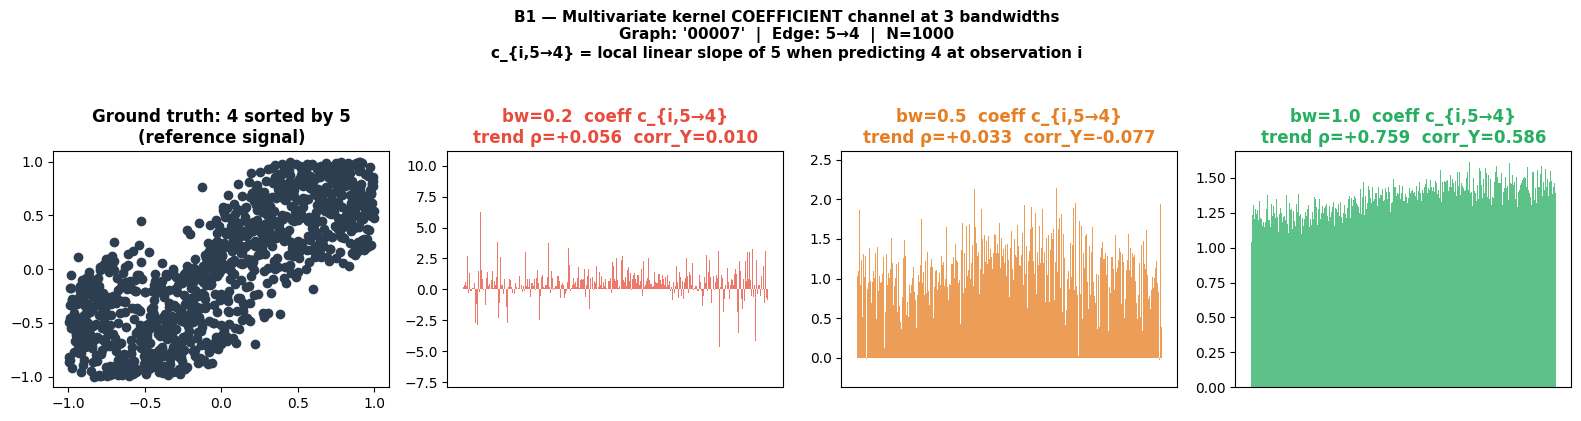

Note: narrow bw = very local slope (noisy); wide bw = global average slope.


In [ ]:
# ── Pick any graph from X_train and any two columns ──────────────────────────
GRAPH_KEY  = "00007"   # None = pick first available; or set e.g. "graph_0042"
COL_SRC    = "5"    # source column (the "cause" direction for the edge)
COL_TGT    = "4"    # target column

key     = GRAPH_KEY or next(iter(X_train))
df_real = X_train[key]

print(f"Graph: {key!r}  |  columns: {list(df_real.columns)}  |  shape: {df_real.shape}")
assert COL_SRC in df_real.columns and COL_TGT in df_real.columns, \
    f"Columns {COL_SRC!r}/{COL_TGT!r} not found. Available: {list(df_real.columns)}"

# ── Build the 2-column data array (same as preprocessing pipeline) ────────────
col_idx  = list(df_real.columns)
src_i    = col_idx.index(COL_SRC)
tgt_i    = col_idx.index(COL_TGT)
data_b   = df_real.values.astype(np.float32)          # (N, p)
N        = data_b.shape[0]

X_b      = data_b[:, src_i]
Y_b      = data_b[:, tgt_i]
sort_X_b = np.argsort(X_b)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].scatter(X_b[sort_X_b], Y_b[sort_X_b], color='#2C3E50')
axes[0].set_title(f'Ground truth: {COL_TGT} sorted by {COL_SRC}\n(reference signal)', fontweight='bold')
# axes[0].set_xticks([])

for ax, bw, color in zip(axes[1:], BANDWIDTHS, BW_COLORS):
    cm  = compute_multivariate_kernel_coefficients(data_b, n_sub=min(1000, N), bandwidth=bw)
    ch  = cm[(src_i, tgt_i)][sort_X_b]
    rho, _       = stats.pearsonr(np.arange(N), ch)
    corr_with_Y  = np.corrcoef(ch, Y_b[sort_X_b])[0, 1]
    ax.bar(range(N), ch, color=color, alpha=0.75, width=1)
    ax.set_title(
        f'bw={bw}  coeff c_{{i,{COL_SRC}→{COL_TGT}}}\ntrend ρ={rho:+.3f}  corr_Y={corr_with_Y:.3f}',
        fontweight='bold', color=color
    )
    ax.set_xticks([])

plt.suptitle(
    f'B1 — Multivariate kernel COEFFICIENT channel at 3 bandwidths\n'
    f'Graph: {key!r}  |  Edge: {COL_SRC}→{COL_TGT}  |  N={N}\n'
    f'c_{{i,{COL_SRC}→{COL_TGT}}} = local linear slope of {COL_SRC} when predicting {COL_TGT} at observation i',
    fontsize=11, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.show()
print('Note: narrow bw = very local slope (noisy); wide bw = global average slope.')

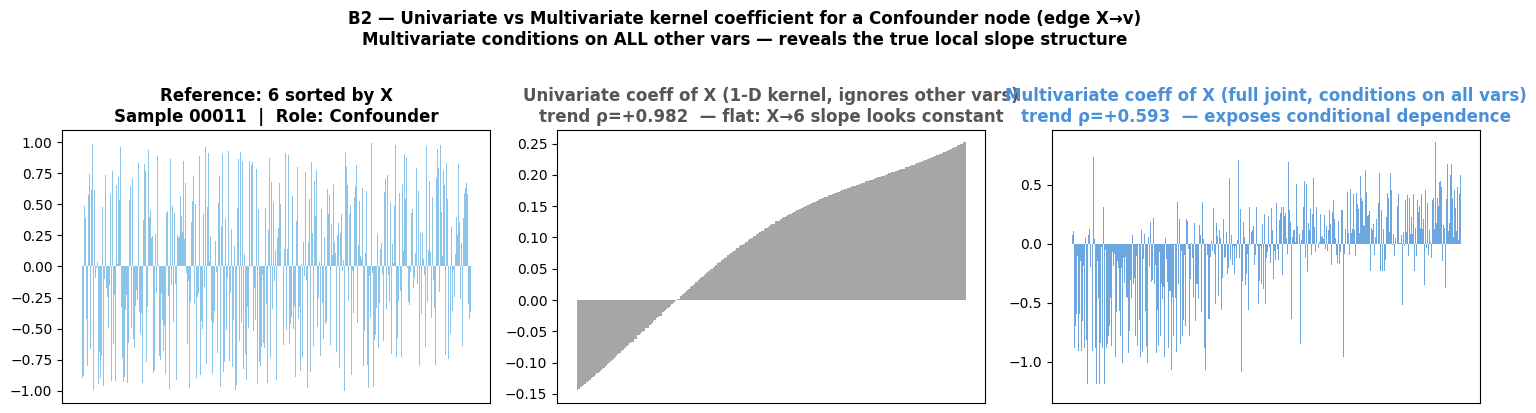

In [ ]:
# ── B2: Univariate vs Multivariate kernel — coefficient channel comparison ──
# Univariate: coeff of X in pairwise regression X→v (ignores all other vars)
# Multivariate: coeff of X in joint regression X+all→v (conditions on rest)
adj_label = get_adjacency_label()
confounder_sample, confounder_node = None, None
for name in train_names:
    lbs = get_labels(y_train[name], adj_label)
    for v, role in lbs.items():
        if role == 'Confounder':
            confounder_sample, confounder_node = name, v
            break
    if confounder_sample:
        break

df_c   = X_train[confounder_sample]
cols_c = list(df_c.columns)
data_c = df_c.values.astype(np.float32)
N_c    = len(data_c)
xi_c   = cols_c.index('X')
vi_c   = cols_c.index(confounder_node)
sort_c = np.argsort(data_c[:, xi_c])   # sort by X (edge X→v)
bw = 0.5

# Univariate: 2-column WLS (intercept + X only), predicting v
n_sub = 400
sub_idx  = np.random.choice(N_c, n_sub, replace=False)
data_sub = data_c[sub_idx]
diff_1d  = (data_sub[:, xi_c:xi_c+1] - data_sub[None, :, xi_c]).squeeze()
W_uni    = np.exp(-diff_1d**2 / (2*bw**2))   # (n_sub, n_sub) — 1D kernel
X_d_uni  = np.column_stack([np.ones(n_sub), data_sub[:, xi_c]])
y_uni    = data_sub[:, vi_c]
A_uni = np.einsum('il,la,lb->iab', W_uni, X_d_uni, X_d_uni)
b_uni = np.einsum('il,la,l->ia',  W_uni, X_d_uni, y_uni)
reg   = 1e-6 * np.eye(2)[None]
c_uni = np.linalg.solve(A_uni + reg, b_uni[:,:,None]).squeeze(-1)  # (n_sub,2)
dist_uni = (data_c[:, xi_c, None] - data_sub[None, :, xi_c])**2    # (N,n_sub)
near_uni = np.argmin(dist_uni, axis=1)
coeff_uni_sorted = c_uni[:, 1][near_uni][sort_c]   # slope of X, sorted by X

# Multivariate: full joint WLS
cm_multi = compute_multivariate_kernel_coefficients(data_c, n_sub=400, bandwidth=bw)
coeff_multi_sorted = cm_multi[(xi_c, vi_c)][sort_c]

rho_uni,   _ = stats.pearsonr(np.arange(N_c), coeff_uni_sorted)
rho_multi, _ = stats.pearsonr(np.arange(N_c), coeff_multi_sorted)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(range(N_c), data_c[sort_c, vi_c], color='#5DADE2', alpha=0.7, width=1)
axes[0].set_title(f'Reference: {confounder_node} sorted by X\n'
                  f'Sample {confounder_sample}  |  Role: Confounder', fontweight='bold')
axes[0].set_xticks([])

axes[1].bar(range(N_c), coeff_uni_sorted, color='#888', alpha=0.75, width=1)
axes[1].set_title(f'Univariate coeff of X (1-D kernel, ignores other vars)\n'
                  f'trend ρ={rho_uni:+.3f}  — flat: X→{confounder_node} slope looks constant',
                  fontweight='bold', color='#555')
axes[1].set_xticks([])

axes[2].bar(range(N_c), coeff_multi_sorted, color='#4A90D9', alpha=0.8, width=1)
axes[2].set_title(f'Multivariate coeff of X (full joint, conditions on all vars)\n'
                  f'trend ρ={rho_multi:+.3f}  — exposes conditional dependence',
                  fontweight='bold', color='#4A90D9')
axes[2].set_xticks([])

plt.suptitle('B2 — Univariate vs Multivariate kernel coefficient for a Confounder node (edge X→v)\n'
             'Multivariate conditions on ALL other vars — reveals the true local slope structure',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── B3: Real data — kernel COEFFICIENT channel variance by role × bandwidth ─
np.random.seed(0)
roles_b3 = ['Cause of X', 'Consequence of X', 'Confounder', 'Independent']
bw_role_var = {bw: {r: [] for r in roles_b3} for bw in BANDWIDTHS}

rng = np.random.default_rng(1)
sample_names_b3 = rng.choice(train_names, size=200, replace=False)

for name in sample_names_b3:
    df_:  pd.DataFrame = X_train[name]
    adj_: pd.DataFrame = y_train[name]
    labels_ = get_labels(adj_, adj_label)
    cols_ = list(df_.columns)
    data_ = df_.values.astype(np.float32)
    xi_   = cols_.index('X')
    sort_ = np.argsort(data_[:, xi_])

    for bw in BANDWIDTHS:
        try:
            cm = compute_multivariate_kernel_coefficients(data_, n_sub=200, bandwidth=bw)
        except Exception:
            continue
        for v, role in labels_.items():
            if role not in roles_b3:
                continue
            vi_ = cols_.index(v)
            # coefficient channel for edge X→v, sorted by X
            ch = cm[(xi_, vi_)][sort_]
            bw_role_var[bw][role].append(np.std(ch))

print('Done. Samples per role/bw:')
for role in roles_b3:
    print(f'  {role:<22}: ' + '  '.join(f'bw={bw} n={len(bw_role_var[bw][role])}' for bw in BANDWIDTHS))

Done. Samples per role/bw:
  Cause of X            : bw=0.2 n=102  bw=0.5 n=102  bw=1.0 n=102
  Consequence of X      : bw=0.2 n=164  bw=0.5 n=164  bw=1.0 n=164
  Confounder            : bw=0.2 n=81  bw=0.5 n=81  bw=1.0 n=81
  Independent           : bw=0.2 n=465  bw=0.5 n=465  bw=1.0 n=465


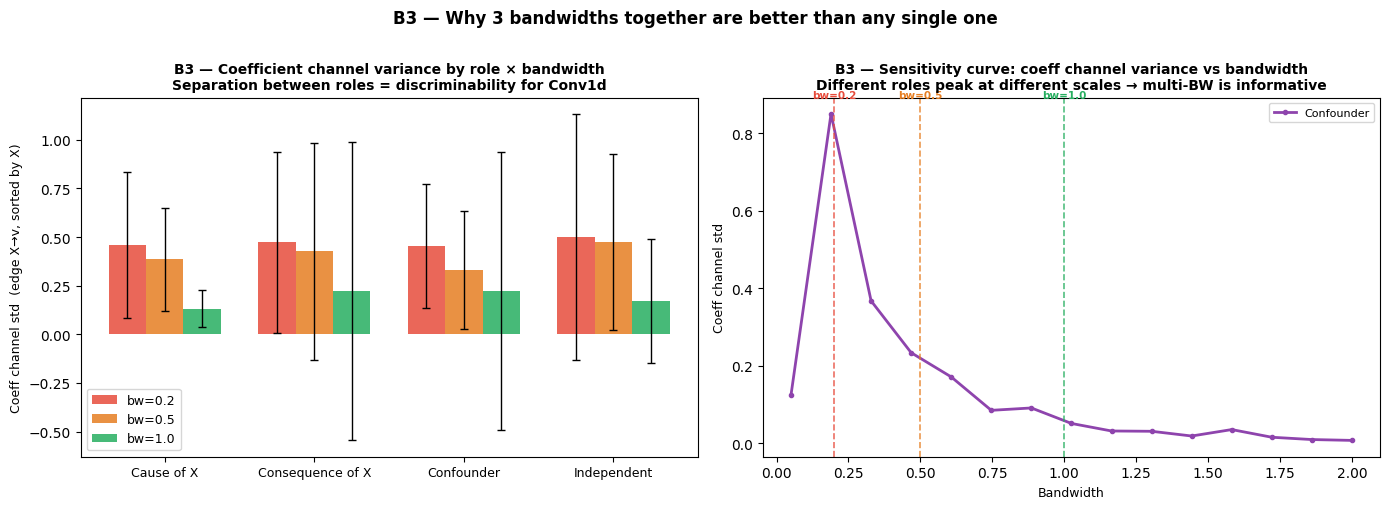

In [ ]:
# ── B3 Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar
ax = axes[0]
x_pos = np.arange(len(roles_b3))
width = 0.25
for bi, (bw, color) in enumerate(zip(BANDWIDTHS, BW_COLORS)):
    means = [np.mean(bw_role_var[bw][r]) if bw_role_var[bw][r] else 0 for r in roles_b3]
    stds  = [np.std(bw_role_var[bw][r])  if bw_role_var[bw][r] else 0 for r in roles_b3]
    ax.bar(x_pos + bi*width, means, width, label=f'bw={bw}',
           color=color, alpha=0.85, yerr=stds, capsize=3, error_kw=dict(lw=1))
ax.set_xticks(x_pos + width)
ax.set_xticklabels(roles_b3, fontsize=9)
ax.set_ylabel('Coeff channel std  (edge X→v, sorted by X)', fontsize=9)
ax.set_title('B3 — Coefficient channel variance by role × bandwidth\n'
             'Separation between roles = discriminability for Conv1d',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# Sensitivity sweep
ax = axes[1]
bw_grid = np.linspace(0.05, 2.0, 15)
role_colors_b3 = {'Cause of X':'#4A90D9','Consequence of X':'#E8613C',
                  'Confounder':'#8E44AD','Independent':'#888'}

df_sw  = X_train[train_names[5]]
adj_sw = y_train[train_names[5]]
labels_sw = get_labels(adj_sw, adj_label)
cols_sw   = list(df_sw.columns)
data_sw   = df_sw.values.astype(np.float32)
xi_sw     = cols_sw.index('X')
sort_sw   = np.argsort(data_sw[:, xi_sw])
role_nodes_sw = {role: cols_sw.index(v)
                 for v, role in labels_sw.items() if role in role_colors_b3}

sensitivity = {role: [] for role in role_nodes_sw}
for bw_v in bw_grid:
    cm_sw = compute_multivariate_kernel_coefficients(data_sw, n_sub=200, bandwidth=bw_v)
    for role, vi in role_nodes_sw.items():
        ch = cm_sw[(xi_sw, vi)][sort_sw]
        sensitivity[role].append(np.std(ch))

for role, color in role_colors_b3.items():
    if role in sensitivity and sensitivity[role]:
        ax.plot(bw_grid, sensitivity[role], color=color, lw=2,
                label=role, marker='o', markersize=3)
for bw_mark, color in zip(BANDWIDTHS, BW_COLORS):
    ax.axvline(bw_mark, color=color, ls='--', lw=1.2, alpha=0.8)
    ax.text(bw_mark, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 1,
            f'bw={bw_mark}', fontsize=7.5, ha='center', color=color, fontweight='bold')
ax.set_xlabel('Bandwidth', fontsize=9)
ax.set_ylabel('Coeff channel std', fontsize=9)
ax.set_title('B3 — Sensitivity curve: coeff channel variance vs bandwidth\n'
             'Different roles peak at different scales → multi-BW is informative',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('B3 — Why 3 bandwidths together are better than any single one',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Computing coefficients for sample 00016 ...  (may take ~10s)
Done.


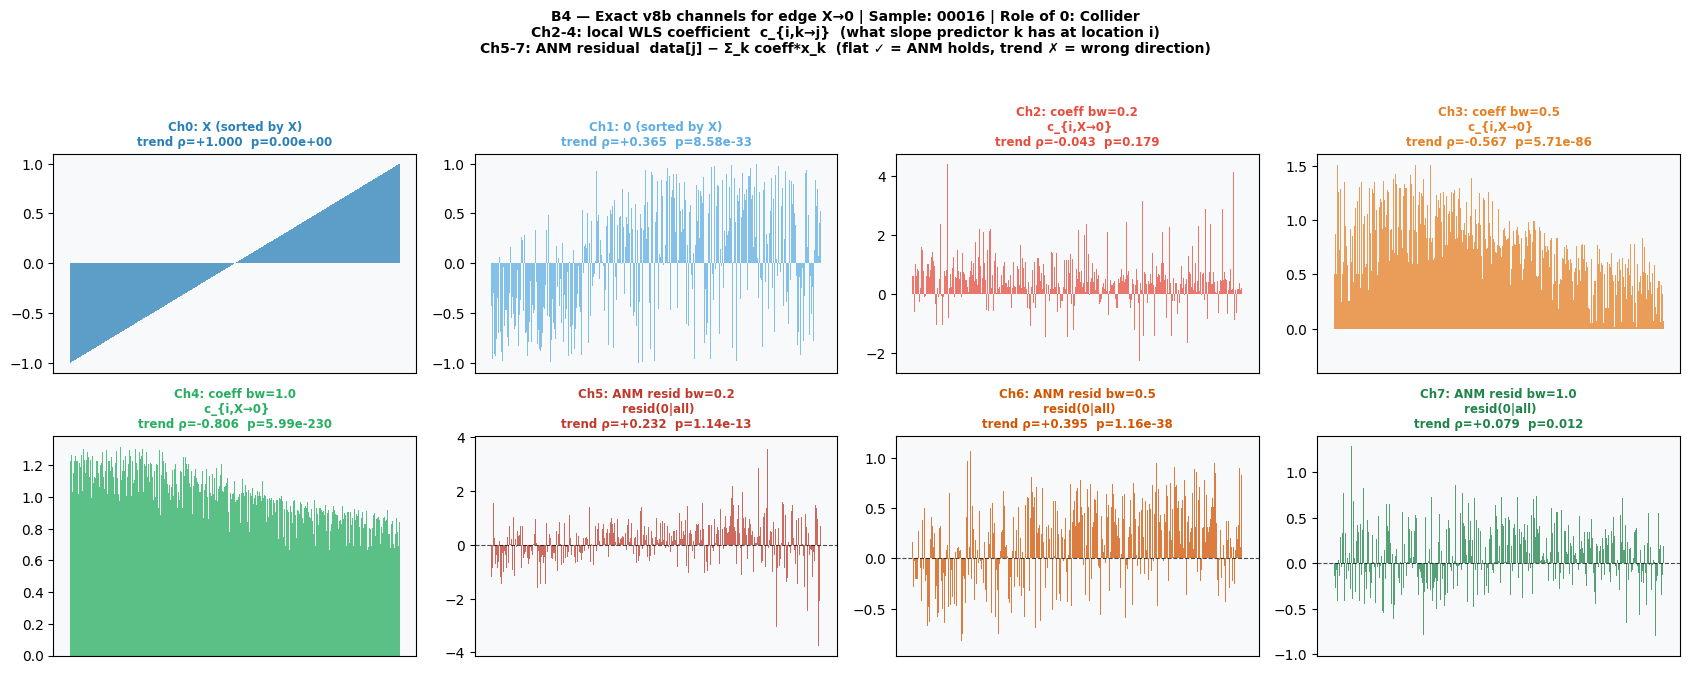


Sample: 00016  |  Edge: X→0  |  Role of 0: Collider

All variables and their roles in this sample:
  0     : Collider ◄ (current TARGET)
  1     : Cause of Y
  2     : Cause of Y
  4     : Confounder

Tip: set SOURCE_NODE="0", TARGET_NODE="X" to flip the edge direction.


In [ ]:
# ── B4: Interactive — what the model ACTUALLY sees (exact v8b channels) ────
# Ch0: source (sorted by source)
# Ch1: target  (sorted by source)
# Ch2-4: coeff_map[(source, target)] at bw=0.2/0.5/1.0  — LOCAL LINEAR SLOPE
# Ch5-7: ANM residual  at bw=0.2/0.5/1.0  — data[:,j] - Σ_k coeff*x_k
#
# Change SAMPLE_IDX / SOURCE_NODE / TARGET_NODE to explore.
# SOURCE is the edge origin (k), TARGET is the edge destination (j).
# For an 'X→v' edge:  SOURCE='X', TARGET=NODE_NAME
# For a  'v→X' edge:  SOURCE=NODE_NAME, TARGET='X'

SAMPLE_IDX  = 5       # index into train_names
SOURCE_NODE = 'X'     # edge source  (sorted axis)
TARGET_NODE = None    # None → auto-pick first non-X/Y variable

name_ex   = train_names[SAMPLE_IDX]
df_ex     = X_train[name_ex]
adj_ex    = y_train[name_ex]
labels_ex = get_labels(adj_ex, adj_label)
cols_ex   = list(df_ex.columns)
data_ex   = df_ex.values.astype(np.float32)

if TARGET_NODE is None:
    TARGET_NODE = [v for v in cols_ex if v not in ('X', 'Y')][0]

ki = cols_ex.index(SOURCE_NODE)   # source col index
ji = cols_ex.index(TARGET_NODE)   # target col index
role_ex = labels_ex.get(TARGET_NODE, labels_ex.get(SOURCE_NODE, '?'))
sort_k  = np.argsort(data_ex[:, ki])   # sort by source

# ── Compute all 3 BW coeff_maps (mirrors v8b build_edge_tensor) ────────────
print(f'Computing coefficients for sample {name_ex} ...  (may take ~10s)')
coeff_maps = {}
resid_maps = {}
for bw in BANDWIDTHS:
    cm = compute_multivariate_kernel_coefficients(data_ex, n_sub=400, bandwidth=bw)
    coeff_maps[bw] = cm
    resid_maps[bw] = compute_anm_residuals(data_ex, cm)
print('Done.')

# ── Assemble all 8 channels exactly as build_edge_tensor would ─────────────
channels = {
    f'Ch0: {SOURCE_NODE} (sorted by {SOURCE_NODE})':            data_ex[sort_k, ki],
    f'Ch1: {TARGET_NODE} (sorted by {SOURCE_NODE})':            data_ex[sort_k, ji],
    f'Ch2: coeff bw=0.2\n c_{{i,{SOURCE_NODE}→{TARGET_NODE}}}': coeff_maps[0.2][(ki, ji)][sort_k],
    f'Ch3: coeff bw=0.5\n c_{{i,{SOURCE_NODE}→{TARGET_NODE}}}': coeff_maps[0.5][(ki, ji)][sort_k],
    f'Ch4: coeff bw=1.0\n c_{{i,{SOURCE_NODE}→{TARGET_NODE}}}': coeff_maps[1.0][(ki, ji)][sort_k],
    f'Ch5: ANM resid bw=0.2\n resid({TARGET_NODE}|all)':        resid_maps[0.2][sort_k, ji],
    f'Ch6: ANM resid bw=0.5\n resid({TARGET_NODE}|all)':        resid_maps[0.5][sort_k, ji],
    f'Ch7: ANM resid bw=1.0\n resid({TARGET_NODE}|all)':        resid_maps[1.0][sort_k, ji],
}
ch_colors = ['#2980B9', '#5DADE2', '#E74C3C', '#E67E22', '#27AE60',
             '#C0392B', '#D35400', '#1E8449']

fig, axes = plt.subplots(2, 4, figsize=(17, 6.5))
axes = axes.flatten()

for ax, (title, ch), color in zip(axes, channels.items(), ch_colors):
    N_ch = len(ch)
    ax.bar(range(N_ch), ch, color=color, alpha=0.75, width=1.0)
    if 'ANM' in title:
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.7)
    rho, pval = stats.pearsonr(np.arange(N_ch), ch)
    pstr = f'p={pval:.2e}' if pval < 0.001 else f'p={pval:.3f}'
    ax.set_title(f'{title}\ntrend ρ={rho:+.3f}  {pstr}',
                 fontsize=8.5, fontweight='bold', color=color)
    ax.set_xticks([])
    ax.set_facecolor('#F8F9FA')

plt.suptitle(
    f'B4 — Exact v8b channels for edge {SOURCE_NODE}→{TARGET_NODE} | '
    f'Sample: {name_ex} | Role of {TARGET_NODE}: {role_ex}\n'
    f'Ch2-4: local WLS coefficient  c_{{i,k→j}}  (what slope predictor k has at location i)\n'
    f'Ch5-7: ANM residual  data[j] − Σ_k coeff*x_k  (flat ✓ = ANM holds, trend ✗ = wrong direction)',
    fontsize=10, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.show()

print(f'\nSample: {name_ex}  |  Edge: {SOURCE_NODE}→{TARGET_NODE}  |  Role of {TARGET_NODE}: {role_ex}')
print(f'\nAll variables and their roles in this sample:')
for v, r in sorted(labels_ex.items()):
    marker = ' ◄ (current TARGET)' if v == TARGET_NODE else ''
    print(f'  {v:<6}: {r}{marker}')
print(f'\nTip: set SOURCE_NODE="{TARGET_NODE}", TARGET_NODE="X" to flip the edge direction.')